In [1]:
import numpy as np
import matplotlib.pylab as plt
import pickle

In [2]:
filename = 'Block5_CGT.pkl'

with open(filename,'rb') as file:
    CGT01 = pickle.load(file)
CGT_Bl5T01 = CGT01

## Methods

In [3]:
#Bond length
b = 2**(1/6)

#Ree parameters
Nlpf = 10009
M = 100; N = 100
Ndata = int(M*N)
Ncols = 9

#Get End-to-end distance
def Ree(D):
    
    # ITEM: ATOMS id mol type xu yu zu vx vy vz
    Nf = D.shape[0]
    
    #Extract all atoms that are type 3
    Type3 = D[D[:,:,2] == 3]
    Type3 = Type3.reshape(Nf, 100, 9)

    #Extract all atoms that are type 4
    Type4 = D[D[:,:,2] == 4]
    Type4 = Type4.reshape(Nf, 100, 9)

    #Extract Position vector
    Type3 = Type3[1:,:,3:6] #Exclude first frame
    Type4 = Type4[1:,:,3:6]

    #Extract End-to-end vector
    dX = Type3-Type4
    Rhp = np.linalg.norm(dX, axis = 2)
    
    return Rhp

#Get segmental end-to-end distance
def segRee(D, Blck, Atom_Type):
    Nf = D.shape[0]
    Mseg = N//Blck*M
    # Reshape by Nf x Mseg x Blck x 9       
    D = D[1:].reshape(Nf-1,Mseg,Blck,9) #exclude first frame

    Xseg = D[:,:,:,3:6]

    if(Atom_Type == 'Hydrophilic'):
        # Get just the odd segments (hydrophilic segments)
        Xhp =  Xseg[:,1::2,:,:]
    elif(Atom_Type == 'Hydrophobic'):
        # Get just the even segments (hydrophobic segments)
        Xhp =  Xseg[:,0::2,:,:]
    
    # End-to-End vectors of the segments
    dX = Xhp[:,:,-1,:]-Xhp[:,:,0,:]
    Rhp = np.linalg.norm(dX,axis=2)
    return Rhp

# Radius of Gyration
# Xcom = Xhp.mean(axis=2)
# dX = Xhp-Xcom[:,:,np.newaxis,:]
# Rg = np.mean((dX**2).sum(axis=3),axis=2)**0.5

# h,edges = np.histogram(Rg.flatten(),bins=100)
# xh = (edges[:-1]+edges[1:])/2
# plt.plot(xh,h,lw=3)

# #Examine trajectory of hydrophobic segments
# #Should be used to examine individual parsed data
# def SegTraj(Rhp):
#     # Plot Some Segmental Trajectories
#     fg,ax = plt.subplots(1,1,figsize=(8,6))

#     Rhp.shape
#     for m in range(1000):
#         ax.plot(Rhp[:,m],'b-',lw=1.5,alpha=0.05)
        
#     for m in np.arange(0,1000,50):
#         ax.plot(Rhp[:,m],'-',lw=2.5)

## Block 5, T = 0.1

In [4]:
#Define bin size and domain of order parameter
bin = 100
domain = [1, 4*b]
rang = np.linspace(domain[0], domain[1], bin + 1)
xh = (rang[:-1]+rang[1:])/2

Text(0.5, 1.0, 'Histogram for Hydrophilic Sections')

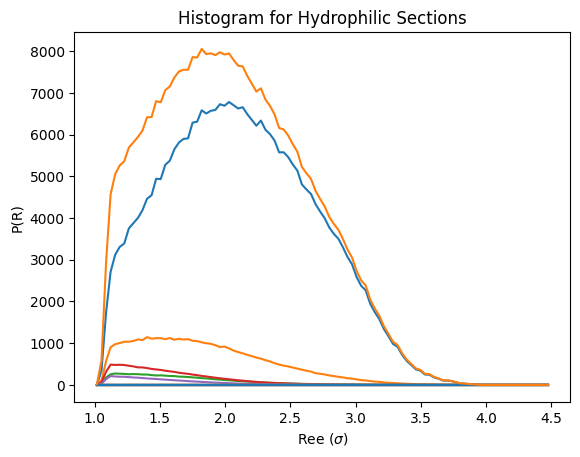

In [5]:
Hphilic = xh*0
for i in range(len(CGT_Bl5T01.ParsedRee)):
    f = CGT_Bl5T01.f[i]
    D = segRee(CGT_Bl5T01.ParsedRee[i], 5, 'Hydrophilic').flatten()
    kT = 0.1
    w = np.exp(-f*D/kT)
    prob = np.histogram(D,bins=rang, weights = w)[0]
    Hphilic += prob
    plt.plot(xh, prob, label = 'f = ' + str(CGT_Bl5T01.f[i]))
plt.plot(xh, Hphilic)
plt.xlabel("Ree ($\sigma$)")
plt.ylabel("P(R)")
plt.title('Histogram for Hydrophilic Sections')

6


/tmp/ipykernel_150474/72630583.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


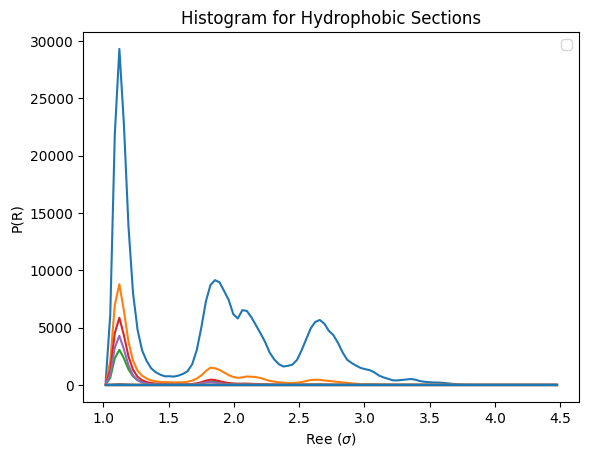

In [6]:
Hphobic = xh*0
for i in range(21):
    f = CGT_Bl5T01.f[i]
    D = segRee(CGT_Bl5T01.ParsedRee[i], 5, 'Hydrophobic').flatten()
    kT = 0.1
    w = np.exp(-f*D/kT)
    prob = np.histogram(D,bins=rang, weights = w)[0]
    Hphobic += prob
    plt.plot(xh, prob)
print(f)
# plt.plot(xh, Hphobic, label='Hphobic')
plt.xlabel("Ree ($\sigma$)")
plt.ylabel("P(R)")
plt.title('Histogram for Hydrophobic Sections')
plt.legend()

/tmp/ipykernel_150474/1698412405.py:4: RuntimeWarning: divide by zero encountered in log
  plt.plot(xh, -0.1*np.log(Hphilic), label = 'Hphilic')
/tmp/ipykernel_150474/1698412405.py:5: RuntimeWarning: divide by zero encountered in log
  plt.plot(xh, -0.1*np.log(Hphobic), label = 'Hphobic')


Text(0, 0.5, 'F ($\\epsilon$)')

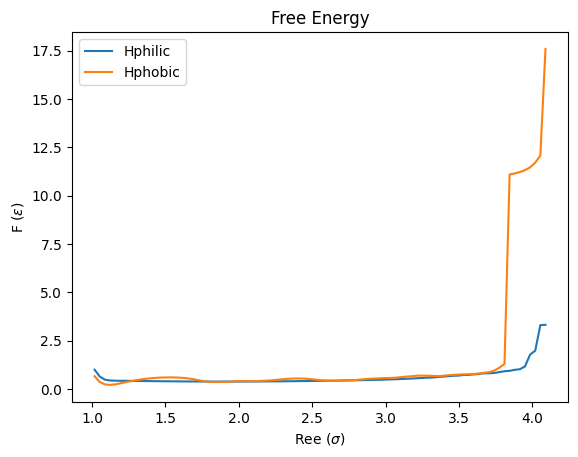

In [7]:
#Free Energy of Hydrophobic and Hydrophilic Sections
Hphobic = Hphobic/Hphobic.sum()
Hphilic = Hphilic/Hphilic.sum()
plt.plot(xh, -0.1*np.log(Hphilic), label = 'Hphilic')
plt.plot(xh, -0.1*np.log(Hphobic), label = 'Hphobic')
plt.legend()
plt.title('Free Energy')
plt.xlabel("Ree ($\sigma$)")
plt.ylabel("F ($\epsilon$)")

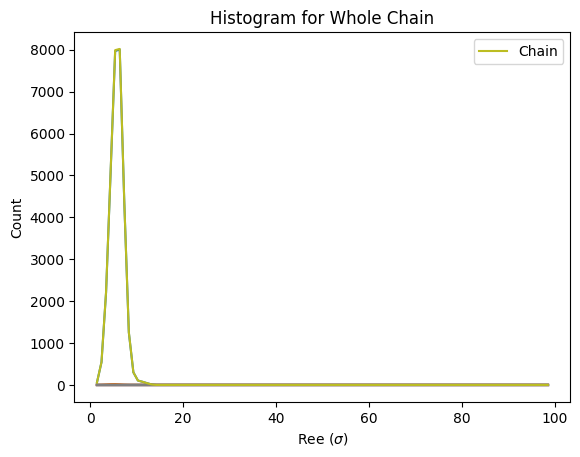

In [8]:
#Whole Chain
#Redefine Range for the whole chain
rang_chain = np.linspace(1, 99, bin+1)
xh_chain = (rang_chain[:-1]+rang_chain[1:])/2
    
Hchain = xh*0
for i in range(18):
    f = CGT_Bl5T01.f[i]
    D = Ree(CGT_Bl5T01.ParsedRee[i]).flatten()
    kT = 0.1
    w = np.exp(-f*D/kT)
    prob = np.histogram(D,bins=rang_chain, weights = w)[0]
    Hchain += prob
    plt.plot(xh_chain, prob)

plt.plot(xh_chain, Hchain, label='Chain')
plt.xlabel("Ree ($\sigma$)")
plt.ylabel("Count")
plt.title('Histogram for Whole Chain')
plt.legend()

/tmp/ipykernel_150474/87255449.py:2: RuntimeWarning: divide by zero encountered in log
  plt.plot(xh_chain, -0.1*np.log(Hchain))


Text(0.5, 1.0, 'Free Energy for Whole Chain')

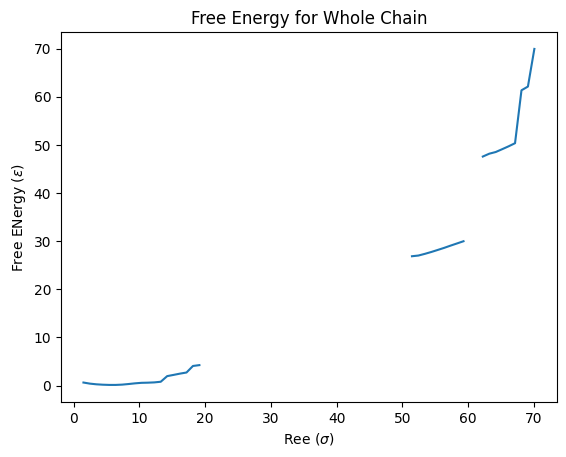

In [9]:
Hchain = Hchain/Hchain.sum()
plt.plot(xh_chain, -0.1*np.log(Hchain))
plt.xlabel("Ree ($\sigma$)")
plt.ylabel("Free ENergy ($\epsilon$)")
plt.title('Free Energy for Whole Chain')

In [10]:
# from pymbar import testsystems
# from pymbar import MBAR
# x_n, u_kn, N_k, s_n = testsystems.HarmonicOscillatorsTestCase().sample()
# mbar = MBAR(u_kn, N_k)
# results = mbar.compute_free_energy_differences()
# diff = results['Delta_f']